Imports and Seed initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from itertools import permutations

STUDENT_ID = 2021030028

#seed initialization based on last 2 digits of ID
seed = int(str(STUDENT_ID)[-2:])
np.random.seed(seed)
style.use('ggplot')

Parameter initialization

In [2]:
# Number of channels (arms)
K = 5

# Users using the channels
users = 2

# Time horizon
T = (2000, 20000)

# Sample baseline SNR parameters
baseline_snr = np.random.uniform(0.8, 2.0, (users, K))

# Instantaneous SNR epsilon
epsilon = 0.6

# All channel permutations that satisfy i != j
actions = list(permutations(range(K), 2))

# Max possible SNR
max_reward = np.log(1 + 10 * (2.0 + epsilon))

# Monte Carlo Epochs
epochs = 50

Functions

In [3]:
# Channel rate
def channel_rate(user, channel, instant_snr):
    rate = np.log(1 + (10 * instant_snr[user, channel]))
    return rate

# Reward for action
def reward_func(action, instant_snr):
    reward = channel_rate(0, action[0], instant_snr) + channel_rate(1, action[1], instant_snr)
    return reward

# Expected Monte Carlo Approximation rewards
def expected_rate(snr, n_samples=100000):
    samples = np.random.uniform(snr - epsilon, snr + epsilon, n_samples)
    return np.mean(np.log(1 + 10 * samples))

In [4]:
class UCB():
    def __init__(self, n_arms, max_reward):
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.arms = n_arms
        self.max_reward = max_reward

    def select_arm(self):
        for arm in range(self.arms):
            if self.counts[arm] == 0:
                return arm
        t = np.sum(self.counts)
        ucb_values = self.values + self.max_reward * np.sqrt((2 * np.log(t)) / self.counts)
        return int(np.argmax(ucb_values))

    def update(self, chosen_arm, reward):
            self.counts[chosen_arm] += 1
            n = self.counts[chosen_arm]

            value = self.values[chosen_arm]
            self.values[chosen_arm] = value + ((reward - value) / n)
            return

### CASE A

In [5]:
def case_A(T):

    # Calculate Expected Reward and 
    expected_rewards = np.zeros(len(actions))
    for idx, (ch1, ch2) in enumerate(actions):
        expected_rewards[idx] = expected_rate(baseline_snr[0, ch1]) + expected_rate(baseline_snr[1, ch2])
    best_action_idx = np.argmax(expected_rewards)
    optimal_reward = expected_rewards[best_action_idx]

    mc_rewards = np.zeros((epochs, T))
    
    for e in range(epochs):
        np.random.seed(seed * 28 + e)

        agent = UCB(len(actions), max_reward)

        for t in range(T):
            instant_snr = np.random.uniform(baseline_snr - epsilon, baseline_snr + epsilon)
            
            chosen_arm = agent.select_arm()

            reward = reward_func(actions[chosen_arm], instant_snr)

            agent.update(chosen_arm, reward)
            
            mc_rewards[e, t] = reward
    
    
    time_axis = np.arange(1, T + 1)
    avg_rewards_per_round = np.mean(mc_rewards, axis=0)
    regret_per_round = optimal_reward - avg_rewards_per_round
    cum_reward = np.cumsum(avg_rewards_per_round)
    cum_regret = np.cumsum(regret_per_round)
    best_cum_reward = optimal_reward * time_axis

    return time_axis, cum_reward, best_cum_reward, cum_regret, regret_per_round

### CASE B

In [6]:
def case_B(T):
    expected_rewards = np.zeros(len(actions))
    for idx, (ch1, ch2) in enumerate(actions):
        expected_rewards[idx] = expected_rate(baseline_snr[0, ch1]) + expected_rate(baseline_snr[1, ch2])

    best_action_idx = np.argmax(expected_rewards)
    optimal_reward = expected_rewards[best_action_idx]

    mc_rewards = np.zeros((epochs, T))

    for e in range(epochs):
        np.random.seed(seed * 28 + e)

        agent1 = UCB(K, max_reward)
        agent2 = UCB(K, max_reward)

        for t in range(T):
            instant_snr = np.random.uniform(baseline_snr - epsilon, baseline_snr + epsilon)

            best_action = -1
            best_ucb_val = -np.inf
            t_curr = t + 1

            for idx, (ch1, ch2) in enumerate(actions):
                if agent1.counts[ch1] == 0:
                    ucb1 = np.inf
                else:
                    ucb1 = agent1.values[ch1] + agent1.max_reward * np.sqrt((2 * np.log(t_curr)) / agent1.counts[ch1])

                if agent2.counts[ch2] == 0:
                    ucb2 = np.inf
                else:
                    ucb2 = agent2.values[ch2] + agent2.max_reward * np.sqrt((2 * np.log(t_curr)) / agent2.counts[ch2])

                joint_ucb = ucb1 + ucb2

                if joint_ucb > best_ucb_val:
                    best_ucb_val = joint_ucb
                    best_action = idx

            ch1, ch2 = actions[best_action]

            reward_1 = channel_rate(0, ch1, instant_snr)
            reward_2 = channel_rate(1, ch2, instant_snr)

            agent1.update(ch1, reward_1)
            agent2.update(ch2, reward_2)

            mc_rewards[e, t] = reward_1 + reward_2

    time_axis = np.arange(1, T + 1)
    avg_rewards_per_round = np.mean(mc_rewards, axis=0)
    regret_per_round = optimal_reward - avg_rewards_per_round
    cum_reward = np.cumsum(avg_rewards_per_round)
    cum_regret = np.cumsum(regret_per_round)
    best_cum_reward = optimal_reward * time_axis

    return time_axis, cum_reward, best_cum_reward, cum_regret, regret_per_round

### Execute CASE A and CASE B for time horizon specified

In [11]:
def generate_comparison_plot(T):
    time_axis, cum_reward_A, best_reward, cum_reg_A, rpr_A = case_A(T)
    _, cum_reward_B, _, cum_reg_B, rpr_B = case_B(T)

    fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
    
    # Plot 1: Cumulative Reward
    axs[0].plot(time_axis, best_reward, color='black', linestyle='--', label='Best Possible Reward')
    axs[0].plot(time_axis, cum_reward_A, color='tab:blue', label='Case A (Aggregate)')
    axs[0].plot(time_axis, cum_reward_B, color='tab:cyan', label='Case B (Semi-Bandit)')
    axs[0].set_title(f'Cumulative Reward Comparison (T={T})')
    axs[0].set_ylabel('Reward')
    axs[0].legend()
    
    # Plot 2: Cumulative Regret
    axs[1].plot(time_axis, cum_reg_A, color='purple', label='Case A (Aggregate)')
    axs[1].plot(time_axis, cum_reg_B, color='magenta', label='Case B (Semi-Bandit)')
    axs[1].set_title(f'Cumulative Regret Comparison (T={T})')
    axs[1].set_ylabel('Regret')
    axs[1].legend()
    
    # Plot 3: Regret per Round
    axs[2].plot(time_axis, rpr_A, color='orange', alpha=0.5, label='Case A')
    axs[2].plot(time_axis, rpr_B, color='green', alpha=0.5, label='Case B')
    axs[2].set_title(f'Regret per Round Comparison (T={T})')
    axs[2].set_xlabel('Time steps (t)')
    axs[2].set_ylabel('Regret')
    axs[2].legend()
    
    plt.tight_layout()
    plt.savefig(f'comparison_plot_T{T}.pdf', format='pdf', bbox_inches='tight')
    plt.close(fig)
    
    return fig

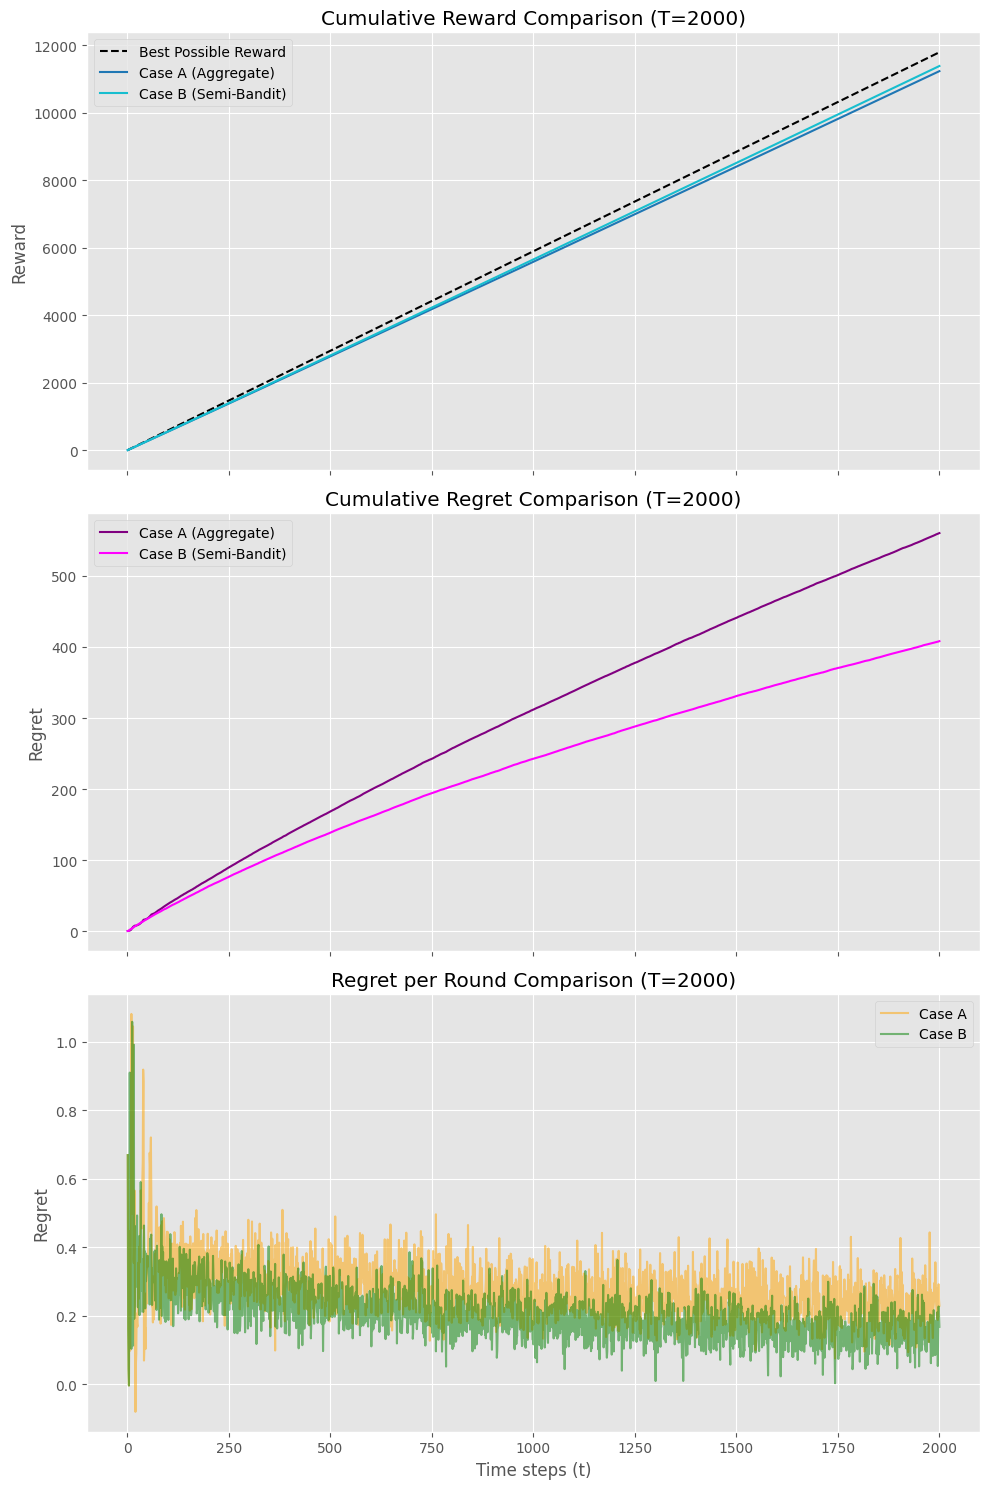

In [12]:
fig1 = generate_comparison_plot(T[0])
fig1

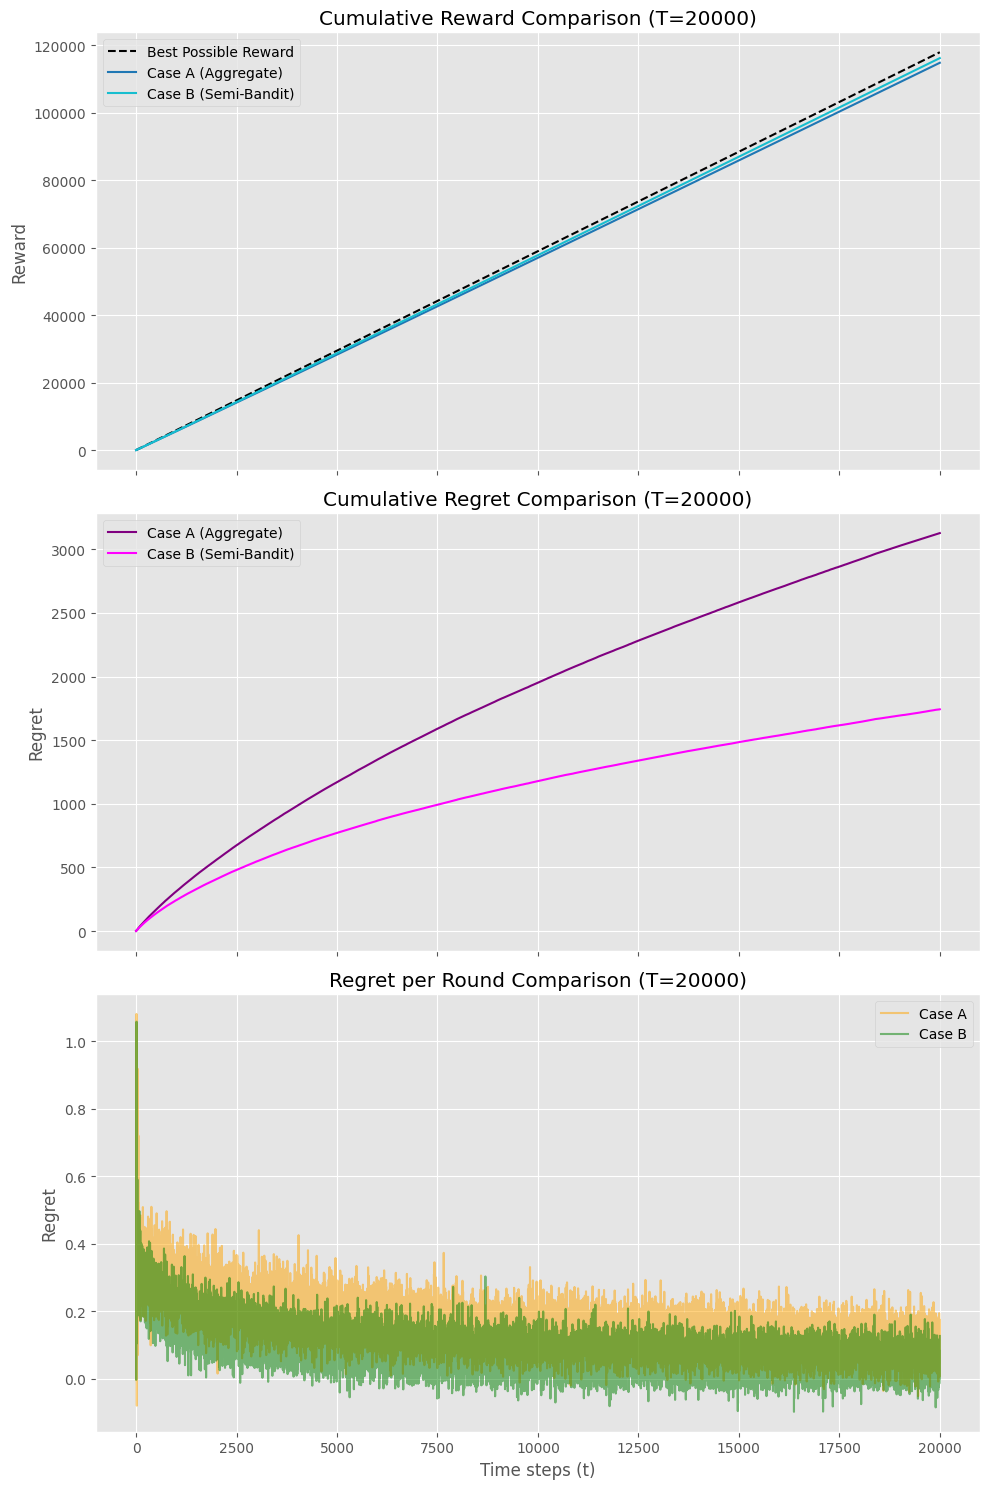

In [14]:
fig2 = generate_comparison_plot(T[1])
fig2